In [260]:
import os
import rasterio
import rioxarray as rxr
from matplotlib.pyplot import tight_layout
from scipy.stats import linregress
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re
import glob
from pathlib import Path


In [261]:
def find_date_directories(start_dir):
    """
    Finds all directories within start_dir whose names are exactly 6 digits.

    Args:
        start_dir (str): The path to the directory to start searching from.

    Returns:
        list: A list of full paths to the matching directories.
    """
    # Regex pattern to match exactly 6 digits
    # ^ asserts the start of the string, \\d{6} matches exactly six digits,
    # and $ asserts the end of the string.
    pattern = re.compile(r"^\d{8}$")
    matching_directories = []

    # os.walk traverses the directory tree recursively
    for root, dirs, files in os.walk(start_dir):
        # We only need to check the directory names (dirs) in the current root
        for dir_name in dirs:
            # Check if the directory name matches the 6-digit pattern
            if pattern.match(dir_name):
                # If it matches, construct the full path and add to the list
                full_path = os.path.join(root, dir_name)
                matching_directories.append(full_path)
    
    return matching_directories


In [264]:
def process_all_dates(parent_dir, task_number):
    """
    Processes multiple date-named directories to build a nested dictionary of model outputs.

    Args:
        parent_dir (str): The parent directory containing subdirectories named 'YYYYMMDD'.
        task_number (int): The task number (1 or 2).

    Returns:
        dict: A nested dictionary where keys are dates and values are dictionaries
              of model rasters for that date.
    """    
    date_dirs = find_date_directories(parent_dir)
    modeled_data = {}

    for dir in date_dirs:
            date_str = os.path.basename(dir)
            modeled_data[date_str] = {}
            
            raster = glob.glob(os.path.join(dir, 'modeled/SNODAS', "*basin_clip.tif"))
            if raster:
                modeled_data[date_str]['SNODAS-basin'] = raster[0] 
                
            raster = glob.glob(os.path.join(dir, 'modeled/SNODAS', '*MCS_clip.tif'))
            if raster:
                modeled_data[date_str]['SNODAS-MCS'] = raster[0] 
                
            if task_number == 1:
                output_dir = os.path.join(dir, "outputs/task1/rasters")
            else:
                output_dir = os.path.join(dir, "outputs/task2/rasters")
            
            #create lidar dictionary
            raster = glob.glob(os.path.join(output_dir, "*LiDAR_MCS_clip*.tif"))
            if raster:
                modeled_data[date_str]['lidar'] = raster[0]            
            
            #create dcitionary of outputs clipped to basin
            models_basin = {}
            raster_search_pattern = os.path.join(output_dir, "*_basin_clip.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_basin_clip.tif", "").replace("_", "-")
                models_basin[model_name] = raster_path  
             
            if models_basin:
                modeled_data[date_str]['basin_clip'] = models_basin  
            
            #create dictionary of outputs clipped to lidar domain    
            models_lidar = {}
            raster_search_pattern = os.path.join(output_dir, "*_MCS_clip.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_MCS_clip.tif", "").replace("_", "-")
                models_lidar[model_name] = raster_path
    
            if models_lidar:
                modeled_data[date_str]['lidar_clip'] = models_lidar  
                
            #create dictionary of outputs clipped to lidar domain and resampled
            models_resample = {}
            raster_search_pattern = os.path.join(output_dir, "*lidar_resample.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_lidar_resample.tif", "").replace("_", "-")
                models_resample[model_name] = raster_path
    
            if models_resample:
                modeled_data[date_str]['resample'] = models_resample
                
            #create dictionary of outputs differenced from lidar data
            models_diff = {}
            raster_search_pattern = os.path.join(output_dir, "*_lidar_diff.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_lidar_diff.tif", "").replace("_", "-")
                models_diff[model_name] = raster_path
            if models_diff:
                modeled_data[date_str]['diff'] = models_diff
                
                
    return modeled_data


In [265]:
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)

In [266]:
for date in task1.keys():
    print(date)
    
print(task1['20230405'])

20230405
20240315
20240418
20250404
20250501
{'SNODAS-basin': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\modeled/SNODAS\\SNODAS_20230405_basin_clip.tif', 'SNODAS-MCS': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\modeled/SNODAS\\SNODAS_20230405_MCS_clip.tif', 'lidar': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\LiDAR_MCS_clip.tif', 'basin_clip': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_EB_basin_clip.tif', 'HMS-TI': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_TI_basin_clip.tif', 'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\iSnobal_basin_clip.tif', 'SnowModel': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\SnowModel_basin_clip.tif'}, 'lidar_clip': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\2023

In [267]:
date = '20230405'

lidar = task1[date]['lidar']
resample = task1[date]['resample']

lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
lidar = lidar.where(lidar < 5)

for name, model_data in resample.items():
        raster = rxr.open_rasterio(model_data, masked=True).squeeze()
# Flatten
        x = lidar.values.flatten()
        y = raster.values.flatten()
    
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        print(name)
        print(linregress(x_clean, y_clean))


HMS-Energy-Balance
LinregressResult(slope=0.18008760626189826, intercept=1.2326338847382226, rvalue=0.6201725732942579, pvalue=3.2605082335545683e-295, stderr=0.004321942129540416, intercept_stderr=0.011960765331481767)
HMS-Temperature-Index
LinregressResult(slope=0.2674564933560427, intercept=1.680371611548972, rvalue=0.6102608457606115, pvalue=2.2817255705014183e-283, stderr=0.006587288048096349, intercept_stderr=0.018230000345361687)
iSnobal
LinregressResult(slope=0.8824589632738516, intercept=0.08136186518493105, rvalue=0.8716070499041947, pvalue=0.0, stderr=0.00939782713524977, intercept_stderr=0.026011201202772605)
SnowModel
LinregressResult(slope=0.8527069295749012, intercept=-0.034005245121424554, rvalue=0.8104182983280676, pvalue=0.0, stderr=0.011799849276727939, intercept_stderr=0.03280965111677063)


In [ ]:
for key in task1.keys():
    print(key)

In [268]:
regressions = []

def rmse_numpy(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

for key in task1.keys():
    lidar = task1[key]['lidar']
    resample_task1 = task1[key]['resample']
    resample_task2 = task2[key]['resample']
    
    resample = {"Task 1":resample_task1, "Task 2":resample_task2}

    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    
    for task, raster in resample.items():
        for name, model_data in raster.items():
                raster = rxr.open_rasterio(model_data, masked=True).squeeze()
        # Flatten
                x = lidar.values.flatten()
                y = raster.values.flatten()
            
                mask = ~np.isnan(x) & ~np.isnan(y)
                x_clean = x[mask]
                y_clean = y[mask]
                
                regression_result = linregress(x_clean, y_clean)
                
                rmse = rmse_numpy(x_clean, y_clean)
                
                row = {
                    "task": task,
                    "date": key,
                    "model": name,
                    "slope": regression_result.slope,
                    "intercept": regression_result.intercept,
                    "rvalue": regression_result.rvalue,
                    "pvalue": regression_result.pvalue,
                    "stderr": regression_result.stderr,
                    "rmse": rmse
                }
            
                regressions.append(row)
                
    df = pd.DataFrame(regressions)
    df['r-squared'] = df['rvalue']**2
    df.to_csv('regression_results.csv', index=False)
        

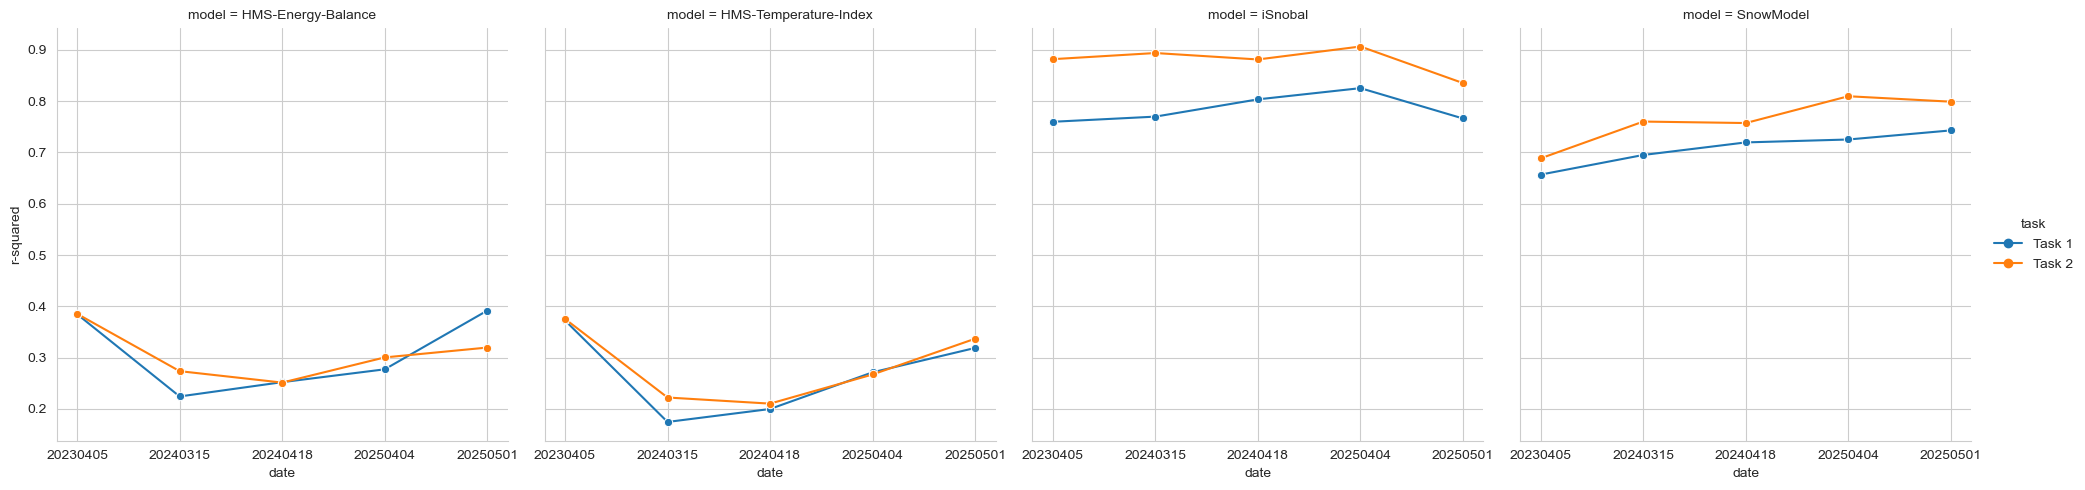

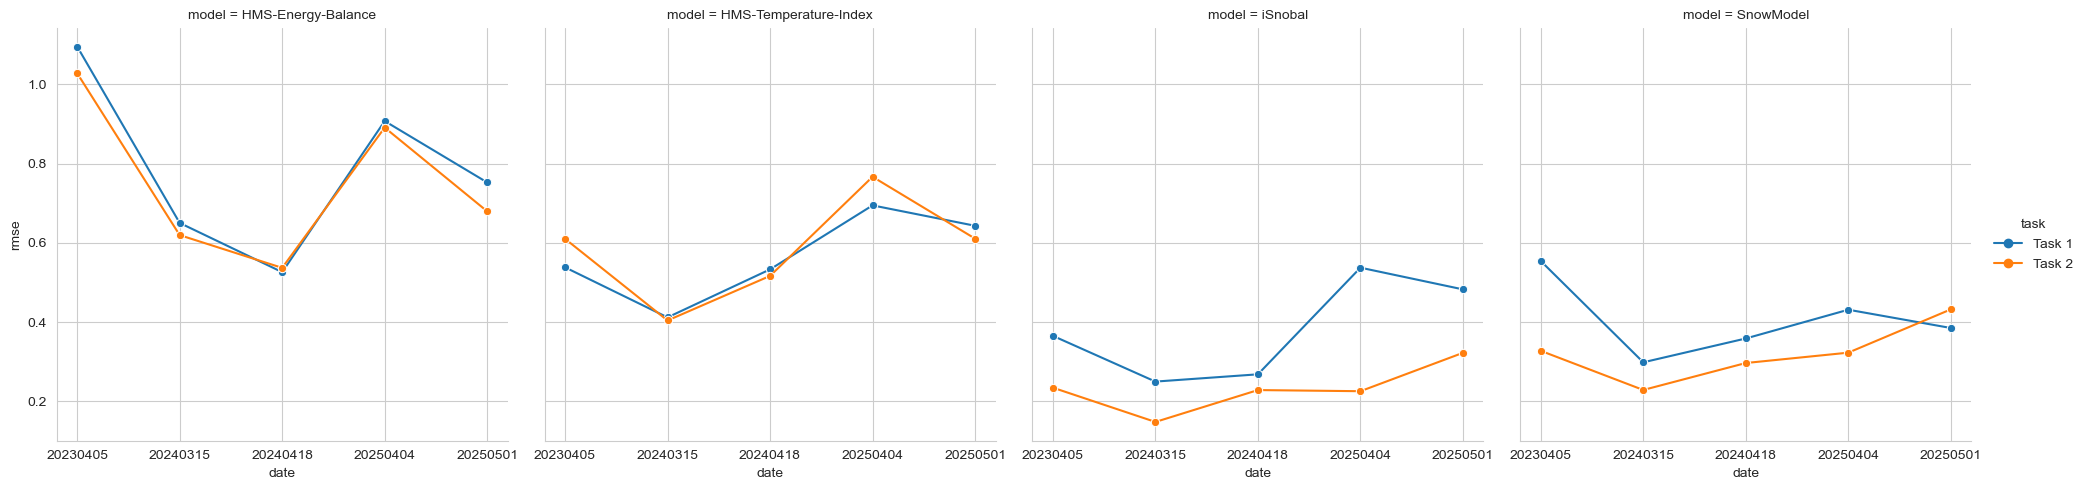

In [270]:
sns.relplot(
    data=df,
    x='date',
    y='r-squared',
    hue='task',
    col='model',
    kind='line',
    marker='o',
    col_wrap=4
)

sns.relplot(
    data=df,
    x='date',
    y='rmse',
    hue='task',
    col='model',
    kind='line',
    marker='o',
    col_wrap=4
)

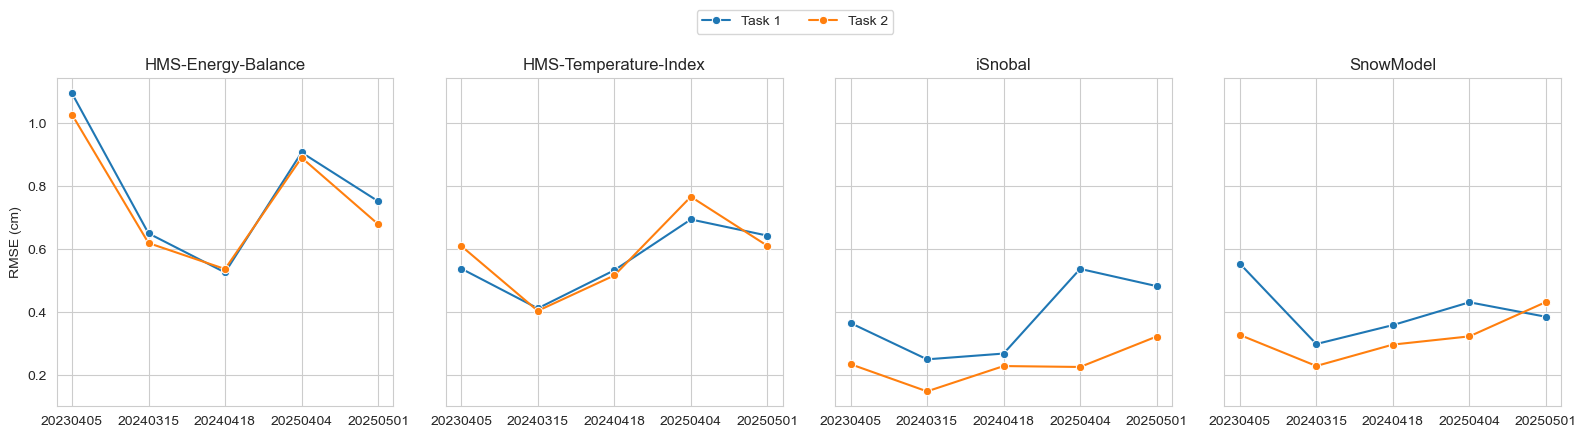

In [273]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4), sharey=True)

models = ['HMS-Energy-Balance', 'HMS-Temperature-Index', 'iSnobal', 'SnowModel']

for i, model in enumerate(models):
    sns.lineplot(
        data=df[df['model'] == model],
        x='date',
        y='rmse',
        hue='task',
        marker='o',
        ax=axs[i],
          
    )
    axs[i].get_legend().remove()
    axs[i].set_title(model)
    axs[i].set_xlabel("")
    #axs[i].tick_params(labelrotation=45)
    axs[0].set_ylabel("RMSE (cm)")
    
    handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3)

plt.tight_layout()
plt.show()

In [ ]:
y1 = rxr.open_rasterio(resample_task1['iSnobal'], masked=True).squeeze()
y2 = rxr.open_rasterio(resample_task2['iSnobal'], masked=True).squeeze()
plt.scatter(lidar, y1, s=5, label='Task 1')
plt.scatter(lidar, y2, s=5, label='Task 2')
plt.legend(loc='upper left')

In [277]:
#date = '20230405'                                                                                      
# Data prep
def comparison_regressions(date):
    resample_task1 = task1[date]['resample']
    resample_task2 = task2[date]['resample']
    
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    
    keys = list(resample_task1.keys())
    plt.figure(figsize=(4, 10))
    for idx in range(1, 5):
        plt.subplot(4, 1, idx)
        current_model1 = keys[idx-1]
        current_model2 = keys[idx-1]
        y1 = rxr.open_rasterio(resample_task1[current_model1], masked=True).squeeze()
        y2 = rxr.open_rasterio(resample_task2[current_model2], masked=True).squeeze()
        plt.scatter(lidar, y1, s=5, label='Task 1')
        plt.scatter(lidar, y2, s=5, label='Task 2')
        plt.legend(loc='upper left')
        plt.title(current_model1)
    plt.tight_layout()
    plt.show()
        

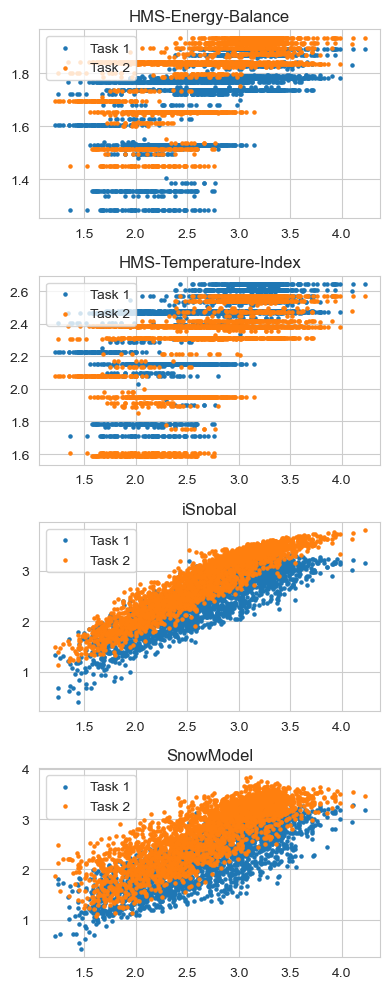

In [278]:
comparison_regressions('20230405')

In [279]:
# Assume 'lidar' is defined somewhere in your script as before

def create_regression_plot(YYYYMMDD, plot_title):
    """
    Generates and displays a 4-panel regression plot for snow depth models.

    Args:
        resample_data (dict): A dictionary where keys are model names and values 
                              are paths to the model's raster data.
        plot_date (str): The date string to be used as the main title for the figure.
    """
    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample = task1[date]['resample']

    # --- Loop through each model to create a subplot ---
    for i, (name, model_data_path) in enumerate(resample.items()):
        raster = rxr.open_rasterio(model_data_path, masked=True).squeeze()
        
        # 1. Flatten and clean data
        x = lidar.values.flatten()
        y = raster.values.flatten()
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]

        ax = axs[i]
        
        # 2. Create the regression plot
        sns.regplot(x=x_clean, y=y_clean, ax=ax,
                    scatter_kws={'alpha': 0.8, 's': 10},
                    line_kws={'color': 'red'})
                    
        # 3. Calculate statistics
        slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        r_squared = r_value**2
        
        # 4. Add titles and labels
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # 5. Add statistics text box
        stats_text = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.2f}x + {intercept:.2f}$'
        ax.text(0.05, 0.95, stats_text, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



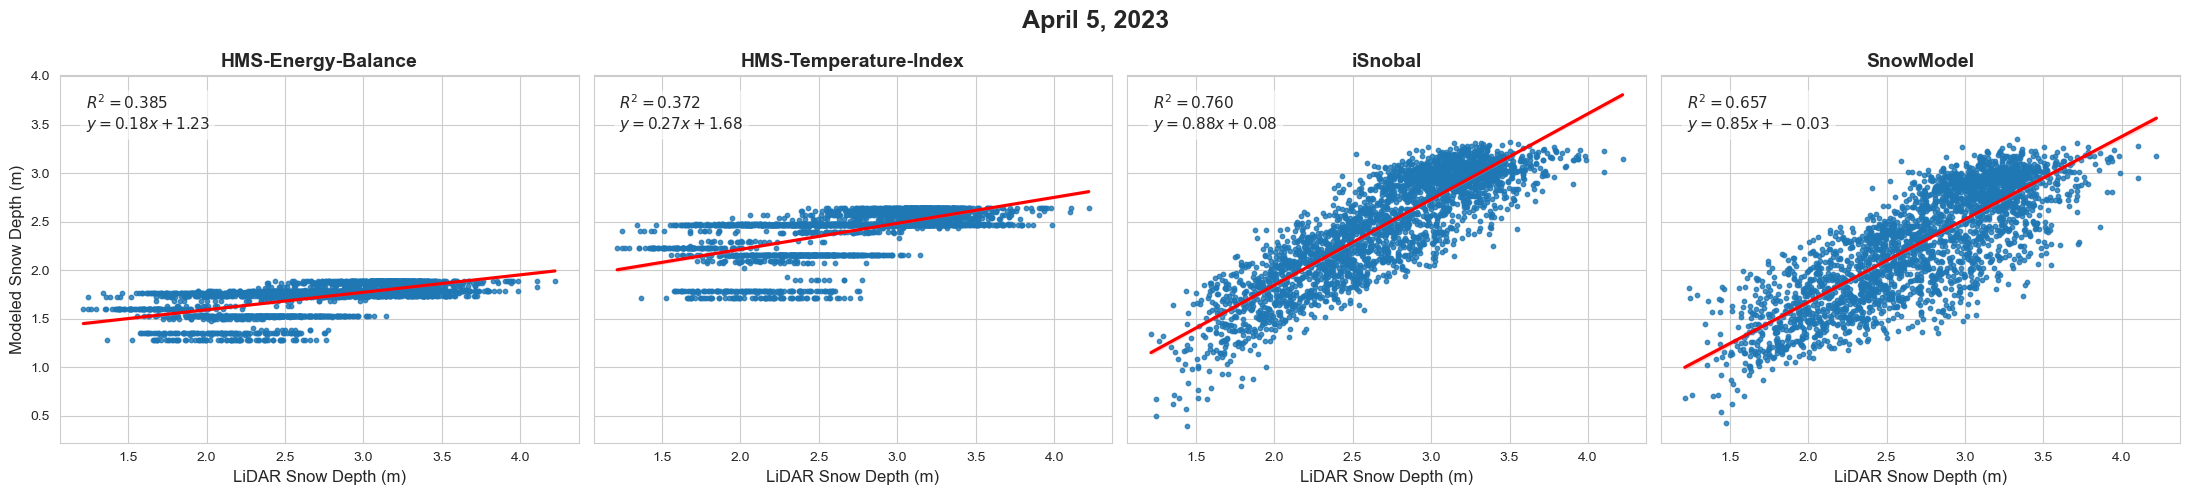

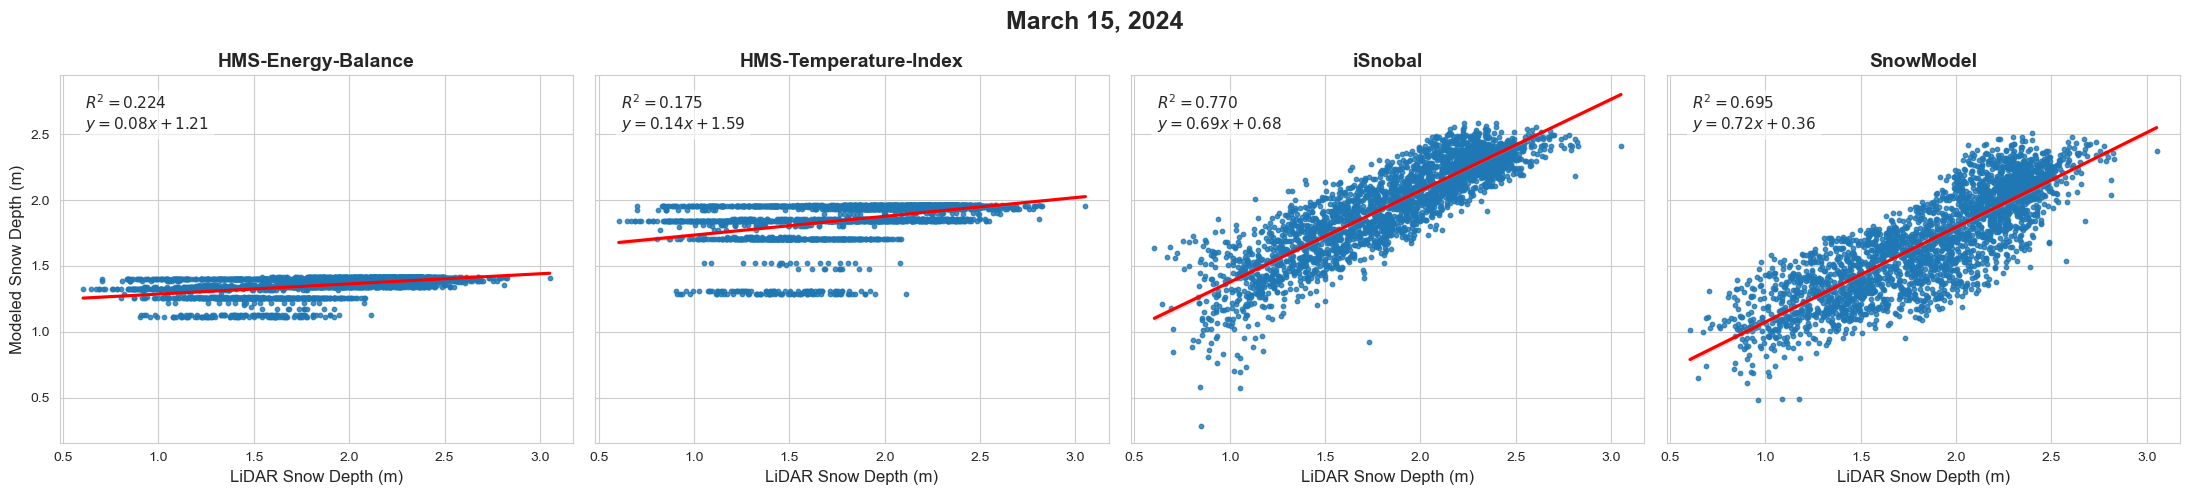

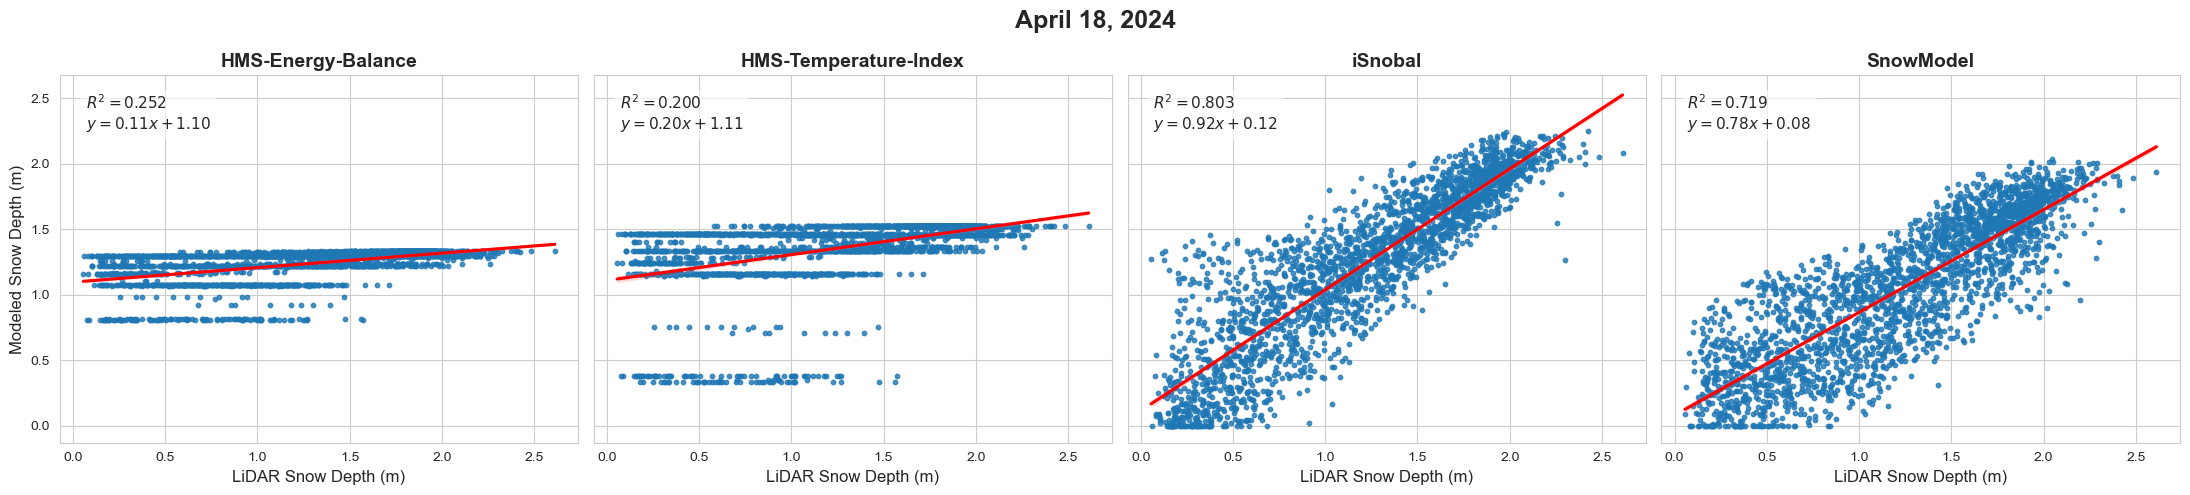

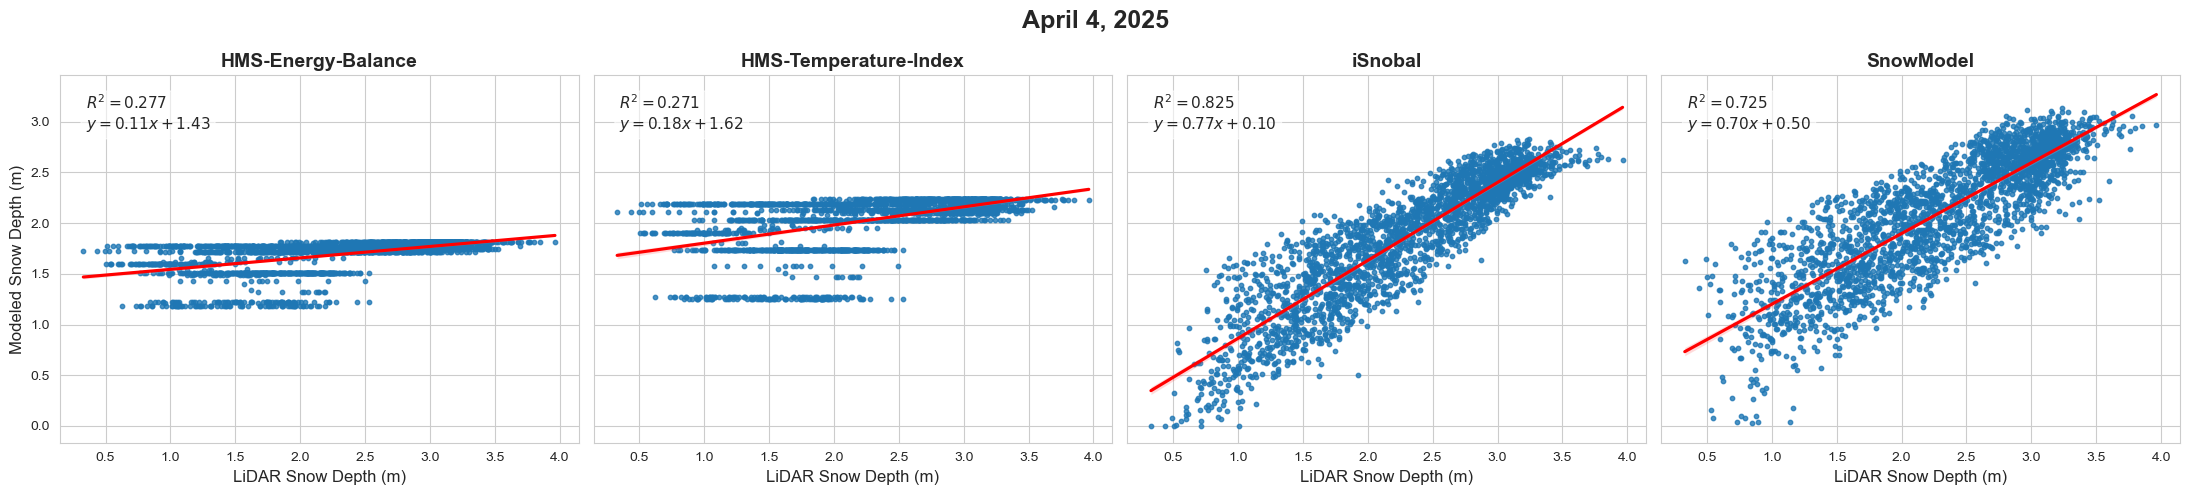

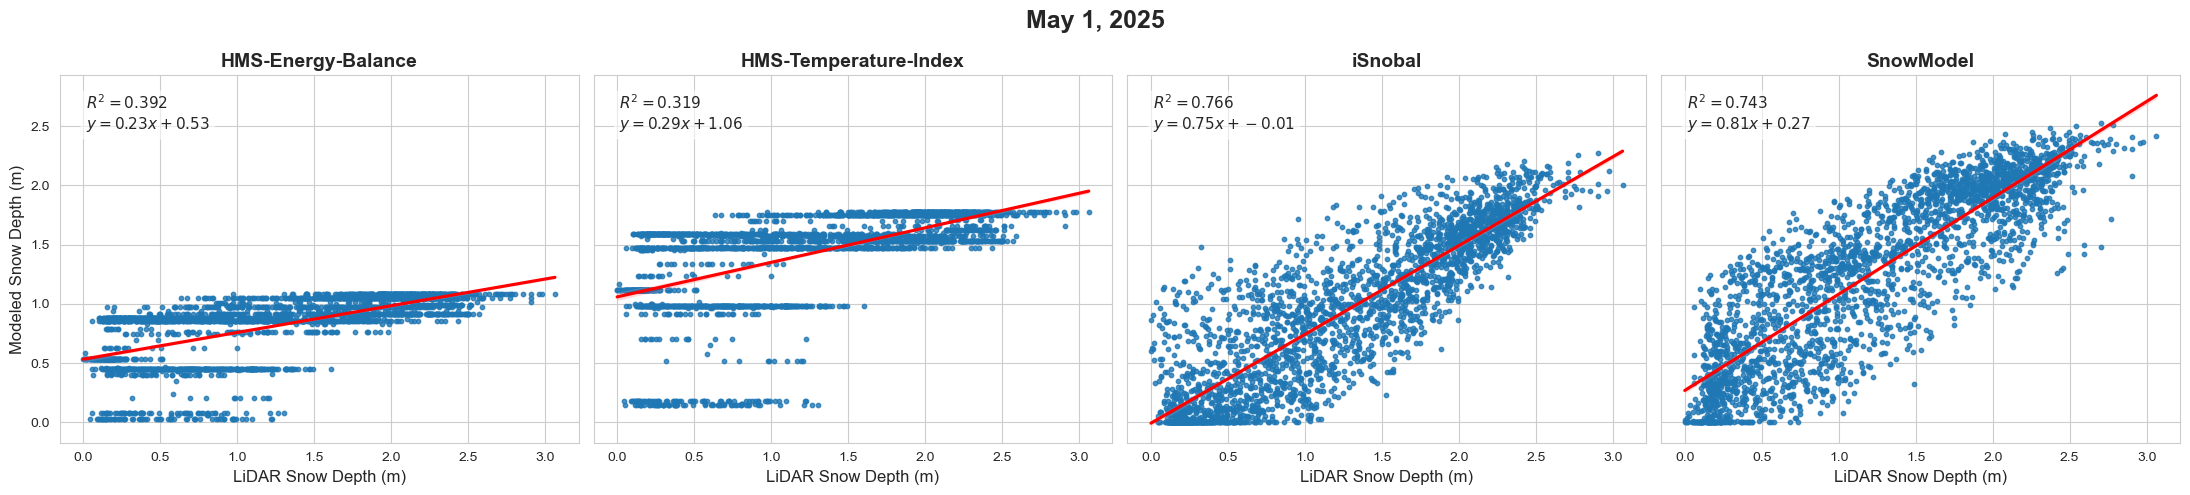

In [280]:
create_regression_plot('20230405', "April 5, 2023")
create_regression_plot('20240315', "March 15, 2024")
create_regression_plot('20240418', "April 18, 2024")
create_regression_plot('20250404', "April 4, 2025")
create_regression_plot('20250501', "May 1, 2025")



In [281]:
# from rasterio.plot import show
   
date = '20230405'
lidar = task1[date]['lidar']
lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
lidar = lidar.where(lidar < 5)
resample_task1 = task1[date]['resample']
resample_task2 = task2[date]['resample']
keys = list(resample_task1.keys())
    
model_name = 'iSnobal'
y1 = rxr.open_rasterio(resample_task1[model_name], masked=True).squeeze()
y2 = rxr.open_rasterio(resample_task2[model_name], masked=True).squeeze()
        
x = lidar.values.flatten()
y1_flat = y1.values.flatten()
y2_flat = y2.values.flatten()

nan_mask = ~np.isnan(x) & ~np.isnan(y1_flat) & ~np.isnan(y2_flat)

x_clean = x[nan_mask]
y1_clean = y1_flat[nan_mask]
y2_clean = y2_flat[nan_mask]

        # slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x, y1_flat)
print(linregress(x_clean, y1_clean))
#         # r_squared1 = r_value1**2
#         # print(slope1, intercept1, r_value1, p_value1, std_err1)
#         
#         # slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x, y2_flat)
print(linregress(x_clean, y2_clean))
        # r_squared2 = r_value2**2
        # print(slope2, intercept2, r_value2, p_value2, std_err2)

LinregressResult(slope=0.8824589632738516, intercept=0.08136186518493105, rvalue=0.8716070499041947, pvalue=0.0, stderr=0.00939782713524977, intercept_stderr=0.026011201202772605)
LinregressResult(slope=1.010370780021502, intercept=0.09219318023150347, rvalue=0.9390051402245881, pvalue=0.0, stderr=0.007006879517649436, intercept_stderr=0.019393563034751628)


In [282]:
# Assume 'lidar' is defined somewhere in your script as before

def regression_plot_compare(YYYYMMDD, plot_title):

    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample_task1 = task1[date]['resample']
    resample_task2 = task2[date]['resample']
    keys = list(resample_task1.keys())
    
    for idx in range(len(resample_task1)):
        ax = axs[idx]
        model_name = keys[idx]
        y1 = rxr.open_rasterio(resample_task1[model_name], masked=True).squeeze()
        y2 = rxr.open_rasterio(resample_task2[model_name], masked=True).squeeze()
        
        x = lidar.values.flatten()
        y1_flat = y1.values.flatten()
        y2_flat = y2.values.flatten()
        
        nan_mask = ~np.isnan(x) & ~np.isnan(y1_flat) & ~np.isnan(y2_flat)

        x_clean = x[nan_mask]
        y1_clean = y1_flat[nan_mask]
        y2_clean = y2_flat[nan_mask]

        sns.regplot(x=x, y=y1_flat, fit_reg=False, ax=axs[idx]) #scatter_kws={'alpha': 0.8, 's': 10})
        sns.regplot(x=x, y=y2_flat, fit_reg=False, ax=axs[idx]) #scatter_kws={'alpha': 0.8, 's': 10})
        start = [0,0]
        end = [4,4]
        ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

        # # 3. Calculate statistics
        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_clean, y1_clean)
        r_squared1 = r_value1**2
        
        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_clean, y2_clean)
        r_squared2 = r_value2**2
        
        # 4. Add titles and labels
        ax.set_title(model_name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # # 5. Add statistics text box
        stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
        ax.text(0.05, 0.95, stats_text1, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
        
        stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
        ax.text(0.35, 0.95, stats_text2, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



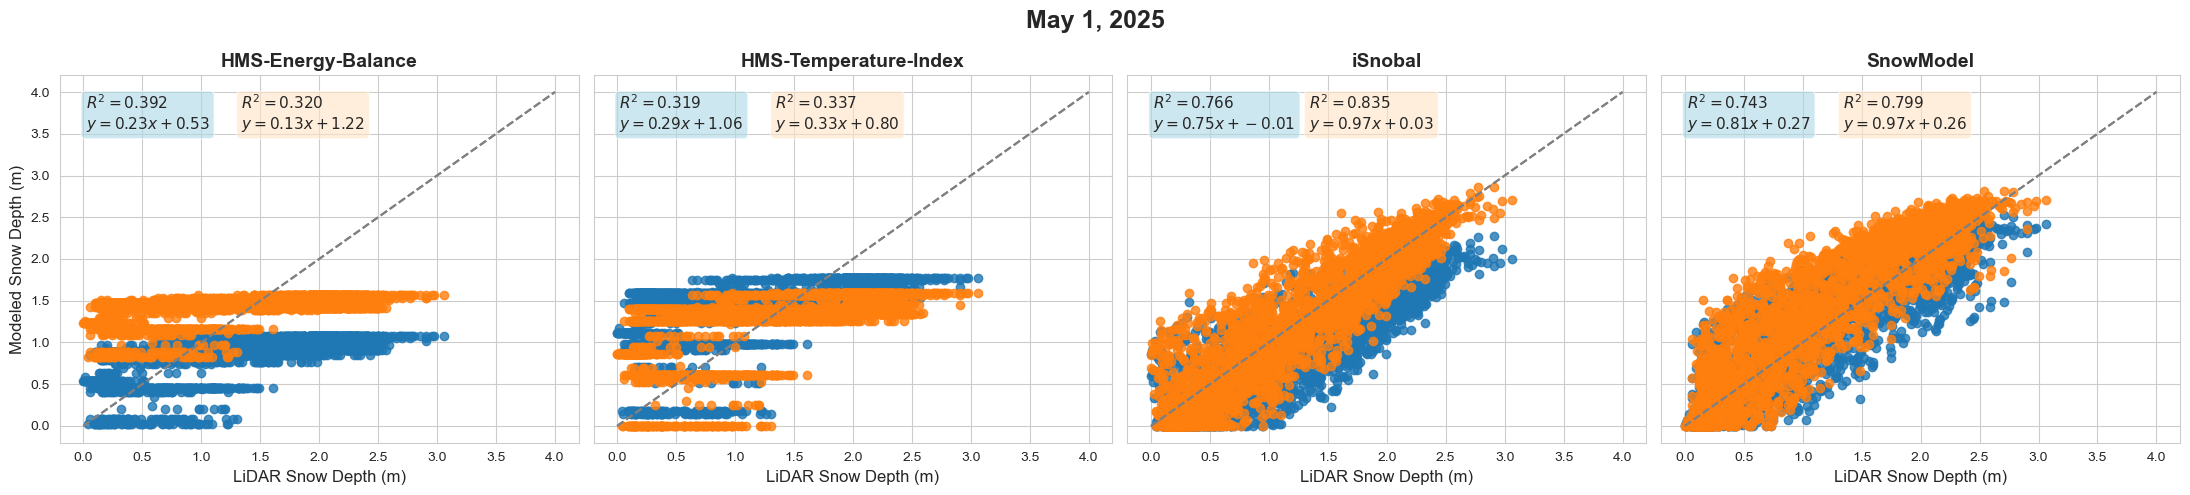

In [283]:
# regression_plot_compare('20230405', "April 5, 2023")
# regression_plot_compare('20240315', "March 15, 2024")
# regression_plot_compare('20240418', "April 18, 2024")
# regression_plot_compare('20250404', "April 4, 2025")
regression_plot_compare('20250501', "May 1, 2025")

In [248]:
diff_list = []
for date in task1.keys():
    diff_task1 = task1[date]['diff']
    diff_task2 = task2[date]['diff']
    diff_list.append(list(diff_task1.values()) + list(diff_task2.values()))

#print(diff_list)
for date in diff_list:
    for filepath in date:
        path = Path(filepath)
        if path.exists():
            print(path)
        else:
            print('File not found--------------------------------------------\n{filepath}\n')

C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\HMS_Energy_Balance_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\HMS_Temperature_Index_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\iSnobal_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\SnowModel_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\HMS_Energy_Balance_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\HMS_Temperature_Index_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\iSnobal_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\SnowModel_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20240315\outputs\task1\rasters\HMS_Energy_Balance_lidar

In [346]:
date = '20230405'

diff_task1 = task1[date]['diff']
diff_task2 = task2[date]['diff']
keys = list(resample_task1.keys())
print(diff_task1)
print(diff_task2)

<built-in method items of dict object at 0x0000020DAD11C9C0>


In [344]:
for i, (model_name, task1_path) in enumerate(diff_task1.items()):
    task2_path = diff_task2[model_name]
    
    print(model_name)
    

HMS-Energy-Balance
HMS-Temperature-Index
iSnobal
SnowModel


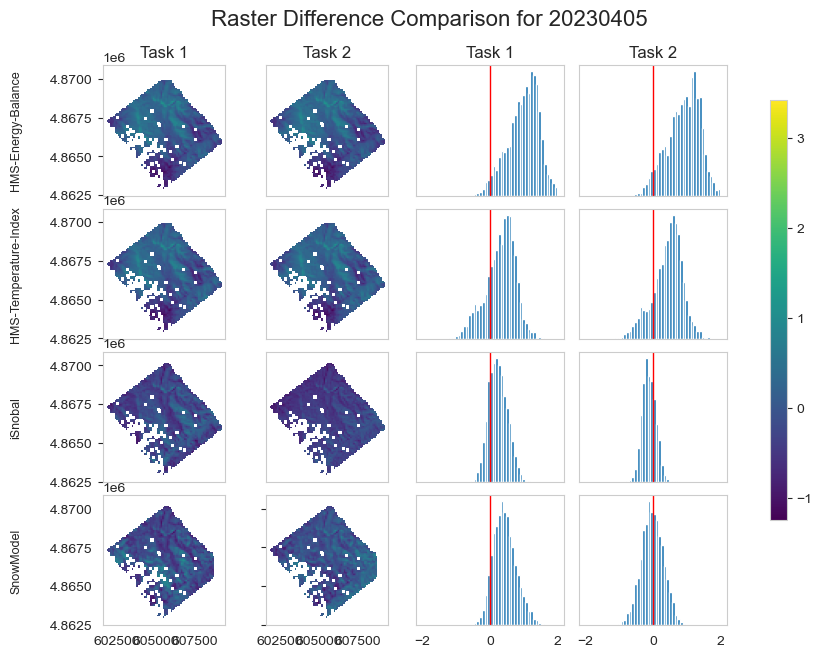

In [372]:
min_fig = -4
max_fig = 4

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(8.5, 7))#, sharex='col')
fig.suptitle(f'Raster Difference Comparison for {date}', fontsize=16)


for i, (model_name, task1_path) in enumerate(diff_task1.items()):
    task2_path = diff_task2[model_name]

    # --- Process and Plot Task 1 ---
    with rasterio.open(task1_path) as src:
        task1_data = src.read(1)
        nodata_val = src.nodata
        bounds = src.bounds
        
        # Plot the raster image in the first column
        ax_img1 = axs[i, 0]
        im = ax_img1.imshow(task1_data, cmap='viridis', extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
        ax_img1.grid(False)
        ax_img1.set_ylabel(model_name, fontsize=9, va="bottom", labelpad=20)

        if i  != 3:
            ax_img1.tick_params(axis='both', which='both', bottom=False, top=False, 
                              left=True, right=False, labelbottom=False, labelleft=True) 
        # Plot the histogram in the second column
        ax_hist1 = axs[i, 2]
        ax_hist1.grid(False)
        task1_flat = task1_data[task1_data != nodata_val].flatten() if nodata_val is not None else task1_data.flatten()
        ax_hist1.hist(task1_flat, bins=50,range=(-2,2))
        ax_hist1.axvline(0, color='red', linestyle='-', linewidth=1)
        if i  != 3:
            ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
                              left=False, right=False, labelbottom=False, labelleft=False)
        else:
            ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
                              left=False, right=False, labelbottom=True, labelleft=False)

    # --- Process and Plot Task 2 ---
    with rasterio.open(task2_path) as src:
        task2_data = src.read(1)
        nodata_val = src.nodata
        
        # Plot the raster image in the third column
        ax_img2 = axs[i, 1]
        ax_img2.grid(False)
        im = ax_img2.imshow(task2_data, cmap='viridis',  extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

        if i == 3:
            ax_img2.tick_params(axis='both', which='both', bottom=False, top=False, 
                              left=True, right=False, labelbottom=True, labelleft=False) 
        else:
            ax_img2.tick_params(axis='both', which='both', bottom=False, top=False, 
                              left=False, right=False, labelbottom=False, labelleft=False) 
        
        # Plot the histogram in the fourth column
        ax_hist2 = axs[i, 3]
        ax_hist2.grid(False)
        task2_flat = task2_data[task2_data != nodata_val].flatten() if nodata_val is not None else task2_data.flatten()
        ax_hist2.hist(task2_flat, bins=50, range=(-2,2))
        ax_hist2.axvline(0, color='red', linestyle='-', linewidth=1)
        
        if i  != 3:
            ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
                              left=False, right=False, labelbottom=False, labelleft=False)
        else:
            ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
                              left=False, right=False, labelbottom=True, labelleft=False)

ax_img1 = axs[0,0]
ax_img2 = axs[0,1]
ax_hist1 = axs[0, 2]
ax_hist2 = axs[0, 3]
ax_img1.set_title('Task 1')
ax_img2.set_title('Task 2')
ax_hist1.set_title('Task 1')
ax_hist2.set_title('Task 2')

plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9, wspace=0.1, hspace=0.1)
cbar_ax = fig.add_axes([0.9, 0.25, 0.02, 0.6]) # [left, bottom, width, height]
# Add the colorbar to the *newly created* axes (cbar_ax)
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
# Adjust layout to prevent titles and labels from overlapping
# Display the plot
plt.show()
